In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
df=sns.load_dataset("titanic")

In [3]:
df.shape

(891, 15)

In [4]:
sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [5]:
# Basic pre processing steps
# q1. how many rows and columns?
df.shape

(891, 15)

In [6]:
# q2. what are the columns names?
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [7]:
#q3. first five rows view?
df.head(5)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [8]:
# q4. last rows view?
df.tail(5)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
886,0,2,male,27.0,0,0,13.00,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.00,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.45,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.00,C,First,man,True,C,Cherbourg,yes,True
890,0,3,male,32.0,0,0,7.75,Q,Third,man,True,NaN,Queenstown,no,True


In [9]:
# q5. random rows or columns
df.sample(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
873,0,3,male,47.0,0,0,9.0000,S,Third,man,True,NaN,Southampton,no,True
779,1,1,female,43.0,0,1,211.3375,S,First,woman,False,B,Southampton,yes,False
313,0,3,male,28.0,0,0,7.8958,S,Third,man,True,NaN,Southampton,no,True
454,0,3,male,NaN,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
400,1,3,male,39.0,0,0,7.9250,S,Third,man,True,NaN,Southampton,yes,True
99,0,2,male,34.0,1,0,26.0000,S,Second,man,True,NaN,Southampton,no,False
793,0,1,male,NaN,0,0,30.6958,C,First,man,True,NaN,Cherbourg,no,True
171,0,3,male,4.0,4,1,29.1250,Q,Third,child,False,NaN,Queenstown,no,False
71,0,3,female,16.0,5,2,46.9000,S,Third,woman,False,NaN,Southampton,no,False
371,0,3,male,18.0,1,0,6.4958,S,Third,man,True,NaN,Southampton,no,False


In [10]:
#q6 what are the datatypes of each column?
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [11]:
# q7. are there any missing values?
df.isna().sum()
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [12]:
# q8. Are there any duplicate rows?
df.duplicated().sum()

np.int64(107)

In [13]:
#
df[df.duplicated()]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
47,1,3,female,NaN,0,0,7.7500,Q,Third,woman,False,NaN,Queenstown,yes,True
76,0,3,male,NaN,0,0,7.8958,S,Third,man,True,NaN,Southampton,no,True
77,0,3,male,NaN,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
87,0,3,male,NaN,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
95,0,3,male,NaN,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
870,0,3,male,26.0,0,0,7.8958,S,Third,man,True,NaN,Southampton,no,True
877,0,3,male,19.0,0,0,7.8958,S,Third,man,True,NaN,Southampton,no,True
878,0,3,male,NaN,0,0,7.8958,S,Third,man,True,NaN,Southampton,no,True
884,0,3,male,25.0,0,0,7.0500,S,Third,man,True,NaN,Southampton,no,True


In [14]:
# q8. statistical overview of numerical columns?
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [15]:
# q9. summary of categorical columns?
df.describe(include='O')

,sex,embarked,who,embark_town,alive
count,891,889,891,889,891
unique,2,3,3,3,2
top,male,S,man,Southampton,no
freq,577,644,537,644,549


In [16]:
# Data Cleaning process:

In [17]:
# 1. Drop duplicates
df.drop_duplicates(inplace=True)

In [18]:
df.isna().mean()*100

survived        0.000000
pclass          0.000000
sex             0.000000
age            13.520408
sibsp           0.000000
parch           0.000000
fare            0.000000
embarked        0.255102
class           0.000000
who             0.000000
adult_male      0.000000
deck           74.234694
embark_town     0.255102
alive           0.000000
alone           0.000000
dtype: float64

In [19]:
df.drop(columns=['deck','class','embarked','alive','adult_male'],inplace=True)

In [20]:
df

,survived,pclass,sex,age,sibsp,parch,fare,who,embark_town,alone
0,0,3,male,22.0,1,0,7.2500,man,Southampton,False
1,1,1,female,38.0,1,0,71.2833,woman,Cherbourg,False
2,1,3,female,26.0,0,0,7.9250,woman,Southampton,True
3,1,1,female,35.0,1,0,53.1000,woman,Southampton,False
4,0,3,male,35.0,0,0,8.0500,man,Southampton,True
...,...,...,...,...,...,...,...,...,...,...
885,0,3,female,39.0,0,5,29.1250,woman,Queenstown,False
887,1,1,female,19.0,0,0,30.0000,woman,Southampton,True
888,0,3,female,NaN,1,2,23.4500,woman,Southampton,False
889,1,1,male,26.0,0,0,30.0000,man,Cherbourg,True


In [21]:
# Exploratory data analysis:
univariate
- categorical columns
- numerical columns
bivariate
-N-N
-N-C
-C-C
multivariate(multiple columns)

In [22]:
# 1. how many survived vs did not survive?
df.survived.value_counts()

survived
0    461
1    323
Name: count, dtype: int64

In [23]:
data=df.survived.value_counts().reset_index()
data

,survived,count
0,0,461
1,1,323


In [24]:
print("survived:",data["count"][1])
print("Not survived:",data["count"][0])

survived: 323
Not survived: 461


<function matplotlib.pyplot.show(close=None, block=None)>

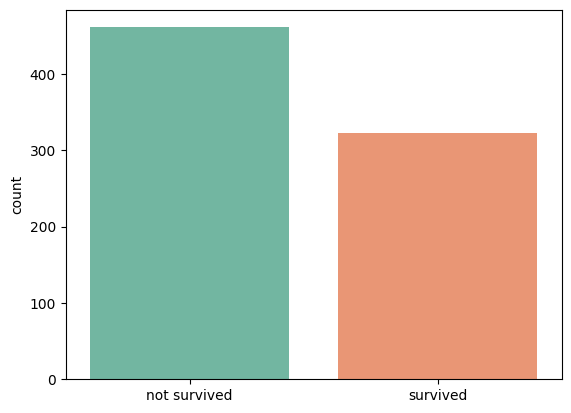

In [30]:
sns.barplot(x=['not survived','survived'],palette="Set2",y=data['count'])
plt.show

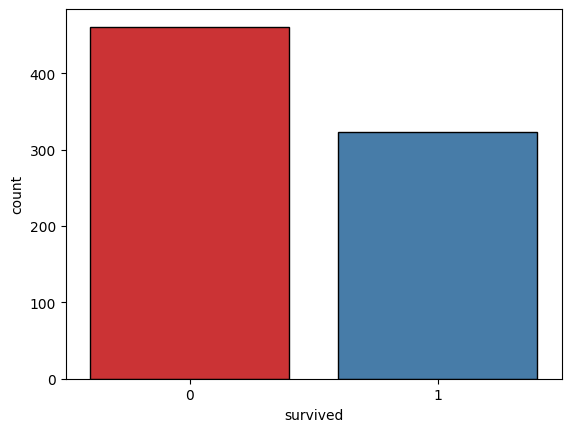

In [25]:
sns.countplot(x=df.survived,palette="Set1",edgecolor="k")
plt.show()

In [26]:
# ques 7. what is the fare distribution and is it skewed?

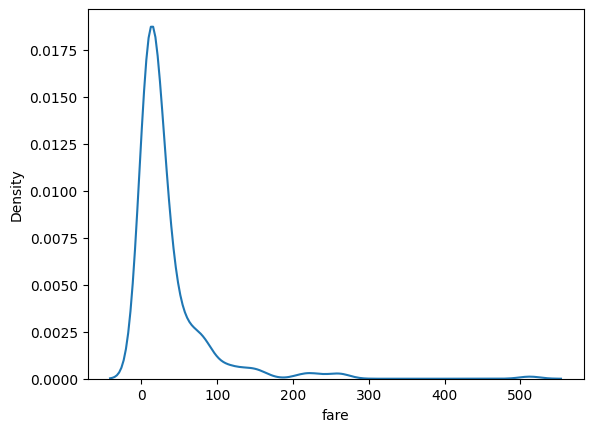

In [27]:
sns.kdeplot(x=df['fare'])
plt.show()

In [28]:
print(df["fare"].skew())
if (df['fare'].skew()>0):
     print("positive skew")
else:
    print("Negative skew")


4.570768460673977
positive skew


In [ ]:
# ques 3 How does the age distribution look? Are there any outliers?

In [31]:
df['age']

0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
885    39.0
887    19.0
888     NaN
889    26.0
890    32.0
Name: age, Length: 784, dtype: float64

<Axes: xlabel='age', ylabel='Count'>

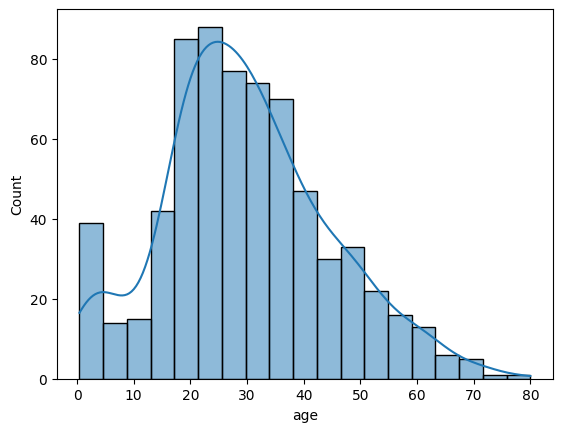

In [33]:
sns.histplot(df["age"],kde=True)

<Axes: xlabel='age', ylabel='Density'>

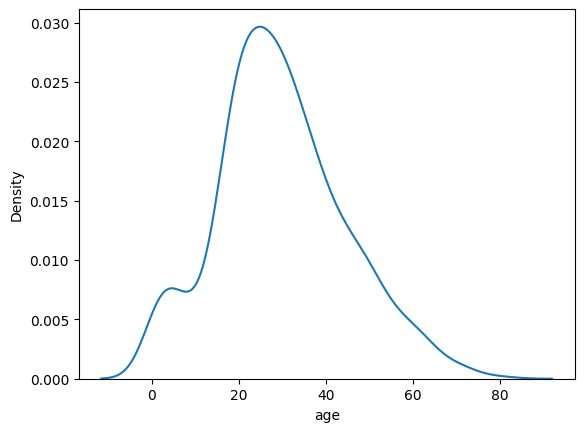

In [35]:
sns.distplot(df["age"],hist=False)

<Axes: ylabel='age'>

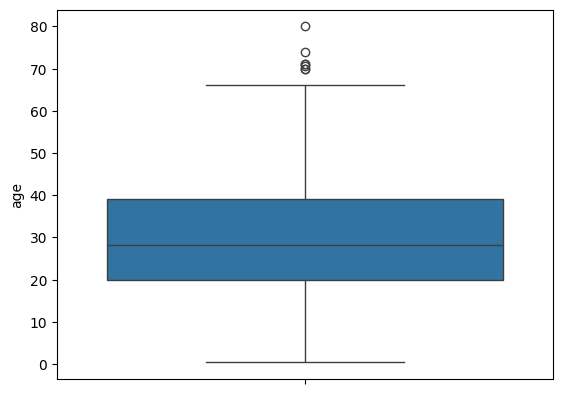

In [36]:
sns.boxplot(y=df["age"])

In [37]:
# q4. what is the gender distribution of passengers?
df["sex"]

0        male
1      female
2      female
3      female
4        male
        ...  
885    female
887    female
888    female
889      male
890      male
Name: sex, Length: 784, dtype: object

<Axes: xlabel='sex', ylabel='count'>

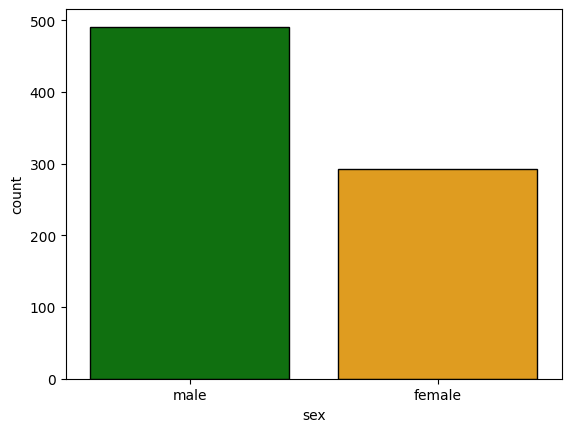

In [40]:
sns.countplot(x=df["sex"],palette=['g','orange'],edgecolor="k")

([<matplotlib.patches.Wedge at 0x1a6ed32ae90>,
 [Text(-0.4250208782634113, 1.0145724483940013, 'male'),
  Text(0.425021087906607, -1.0145723605710362, 'female')],
 [Text(-0.23182956996186066, 0.5534031536694552, '62.6%'),
  Text(0.23182968431269468, -0.5534031057660196, '37.4%')])

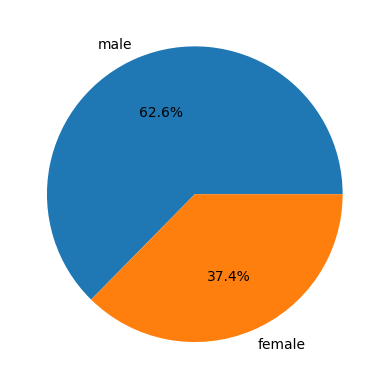

In [44]:
gender=df["sex"].value_counts().reset_index()
gender
plt.pie(gender["count"],labels=gender["sex"],autopct="%1.1f%%")

<Axes: xlabel='sex', ylabel='count'>

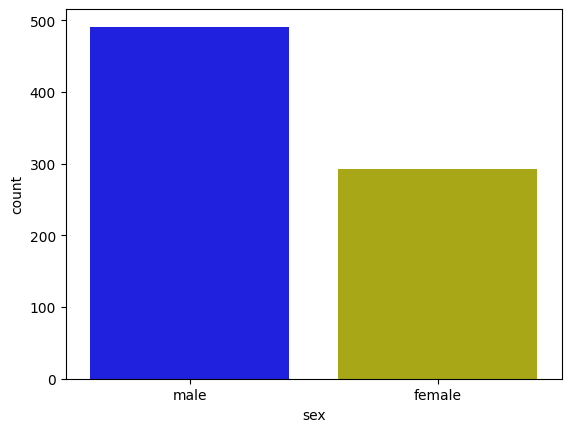

In [45]:
sns.barplot(x=gender["sex"],y=gender["count"],palette=['b','y'])

In [ ]:
# q what is the fare distribution, and is it skewed?

<Axes: xlabel='fare', ylabel='Density'>

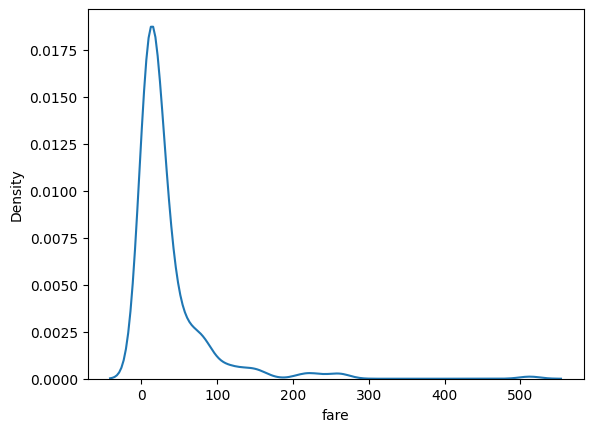

In [46]:
sns.kdeplot(df['fare'])

In [47]:
df['fare'].skew()

np.float64(4.570768460673977)

In [ ]:
# ques What proportion of passengers were travelling alone vs with family?

In [48]:
travel= df['alone'].value_counts().reset_index()
travel

,alone,count
0,True,446
1,False,338


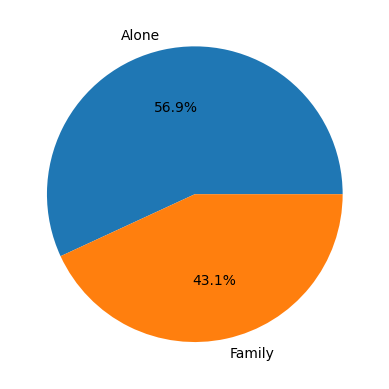

In [50]:
plt.pie(travel['count'],labels=["Alone","Family"],autopct="%1.1f%%")
plt.show()

In [ ]:
 # ques How many children are (age<12) were onboarded

In [52]:
blow_12yr=df["age"][df['age']<12].count()

In [53]:
print("count:",blow_12yr)

count: 67


In [ ]:
# ques How does survival rate differ by gender

<Axes: xlabel='sex', ylabel='count'>

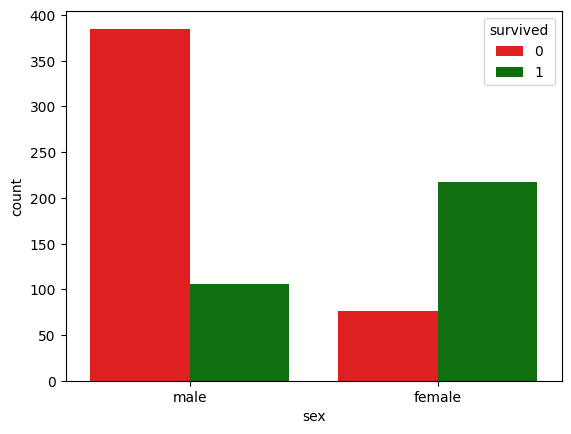

In [55]:
sns.countplot(x=df["sex"],hue=df["survived"],palette=['r','g'])

In [ ]:
# ques. Does age affect survival probability?

<function matplotlib.pyplot.show(close=None, block=None)>

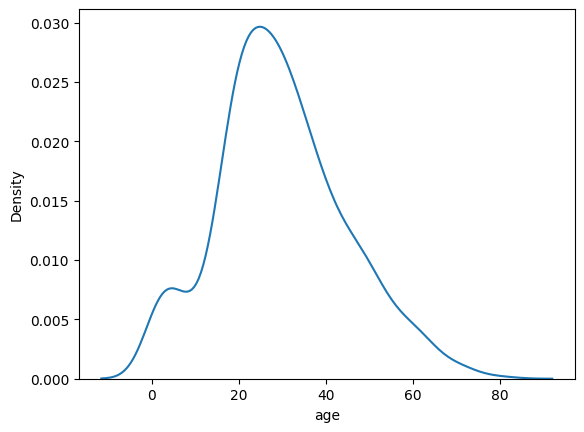

In [57]:
sns.kdeplot(df['age'])
plt.show

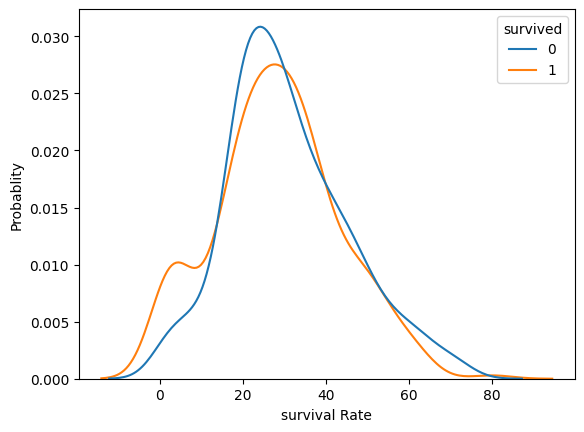

In [61]:
sns.kdeplot(data=df,x="age",hue="survived",common_norm=False)
plt.xlabel("survival Rate")
plt.ylabel("Probablity")
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

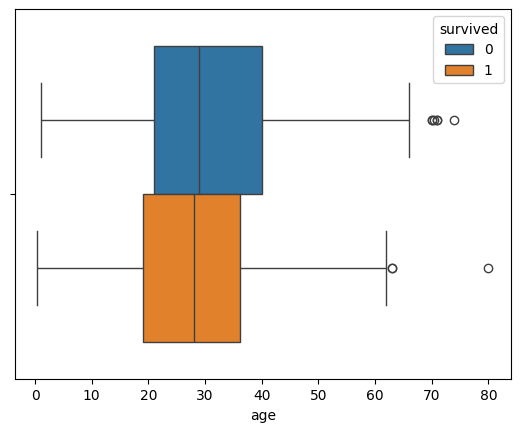

In [60]:
sns.boxplot(data=df,x="age",hue="survived")
plt.show

In [ ]:
# Does embarking port influence survival rate

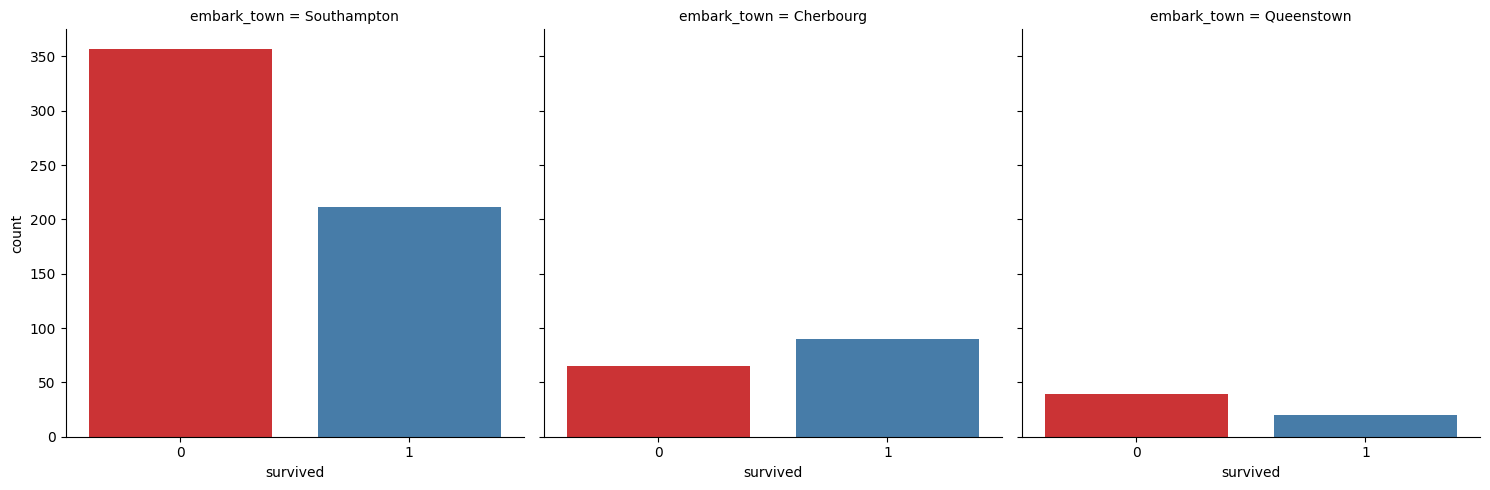

In [62]:
sns.catplot(data=df,x="survived",col="embark_town",kind="count",palette="Set1")

In [66]:
df.groupby(["survived","embark_town"])['pclass'].count().reset_index()

,survived,embark_town,pclass
0,0,Cherbourg,65
1,0,Queenstown,39
2,0,Southampton,357
3,1,Cherbourg,90
4,1,Queenstown,20
5,1,Southampton,211


In [69]:
df.pivot_table(index='embark_town',columns='survived',values='fare',aggfunc='count')

survived,0,1
embark_town,,
Cherbourg,65,90
Queenstown,39,20
Southampton,357,211


In [70]:
D={"name":"Sandeep"}
D

{'name': 'Sandeep'}

In [71]:
D["contact"]=1234567890
D

{'name': 'Sandeep', 'contact': 1234567890}

In [72]:
import pandas as pd
import seaborn as sns
T=sns.load_dataset("titanic")

In [73]:
T

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [74]:
T["Family"]=T["sibsp"]+T["parch"] + 1

In [75]:
T

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,Family
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,2
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,2
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,1
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,2
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True,1
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True,1
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False,4
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True,1


<Axes: xlabel='age', ylabel='Count'>

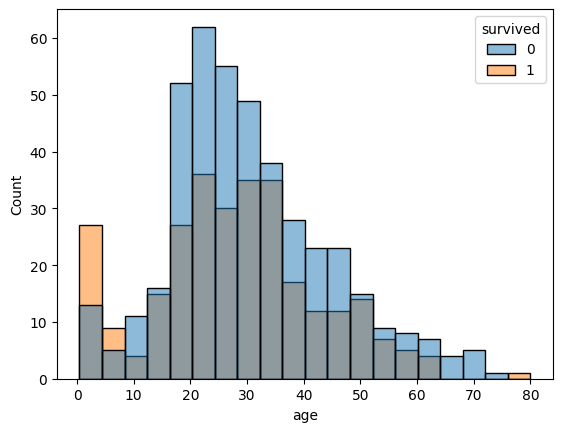

In [77]:
sns.histplot(data=T,x='age',hue='survived')

<Axes: xlabel='age', ylabel='Density'>

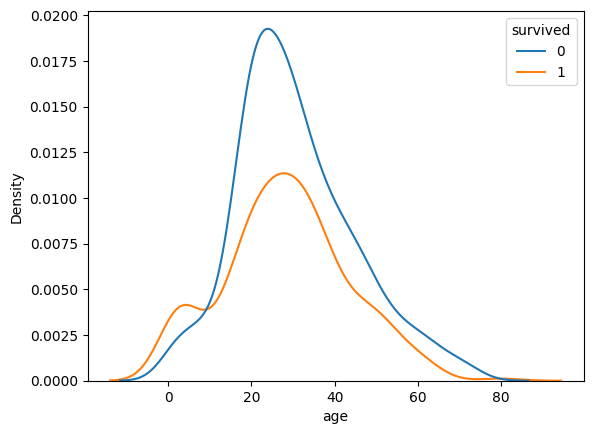

In [78]:
sns.kdeplot(data=T,x='age',hue='survived')